This project aims to develop a machine learning system that recommends the most suitable crop to grow and predicts crop yield based on environmental factors, including weather, rainfall, and climate.

#### Import libraries

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.inspection import permutation_importance

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.metrics import geometric_mean_score


#### Load datasets

In [32]:
df_soil = pd.read_csv('../data/texas.csv')
df_weather = pd.read_csv('../data/texas_weather_2025.csv')

In [33]:
df_soil.head()

,areasymbol,musym,muname,compname,saverest,taxorder,drainagecl,elev_r,slope_r,hzdept_r,hzdepb_r,ph1to1h2o_r,om_r,ec_r,cec7_r,awc_r,cropname,yldunits,nonirryield_r,irryield_r
0,TX129,SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Alfalfa hay,Tons,3.0,6.0
1,TX129,SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Cotton lint,Lbs,225.0,600.0
2,TX129,SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Grain sorghum,Bu,25.0,75.0
3,TX129,AlA,"Altus fine sandy loam, dry, 0 to 1 percent slopes",Altus,9/4/2025 7:20:13 PM,Mollisols,Well drained,662.9,0.5,0,25,6.6,1.5,0.0,9.8,0.13,Grain sorghum,Bu,50.0,NaN
4,TX129,AlA,"Altus fine sandy loam, dry, 0 to 1 percent slopes",Altus,9/4/2025 7:20:13 PM,Mollisols,Well drained,662.9,0.5,0,25,6.6,1.5,0.0,9.8,0.13,Improved bermudagrass,AUM,6.0,NaN


In [34]:
df_weather.head()

,Unnamed: 0,fips_code,month,precip_total_mm,tmax_avg_c,tmin_avg_c
0,0,48001,1,2.412500,12.441935,0.560215
1,1,48001,2,2.075581,16.966667,5.889286
2,2,48001,3,1.655319,24.464130,10.836957
3,3,48001,4,6.247959,26.712222,14.876667
4,4,48001,5,7.215534,28.637634,17.723656


In [35]:
df_soil['fips_code'] = df_soil['areasymbol'].str.replace("TX", "")
# print(df_soil.head())

In [36]:
df_weather['fips_code'] = df_weather['fips_code'].astype(str).replace(r'^\d{2}', "", regex=True)

In [37]:
df_weather = df_weather.drop('Unnamed: 0', axis=1)
# print(df_weather)

In [38]:
df = pd.merge(df_soil, df_weather, on='fips_code')

In [39]:
df.head()

,areasymbol,musym,muname,compname,saverest,taxorder,drainagecl,elev_r,slope_r,hzdept_r,...,awc_r,cropname,yldunits,nonirryield_r,irryield_r,fips_code,month,precip_total_mm,tmax_avg_c,tmin_avg_c
0,TX129,SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,...,0.1,Alfalfa hay,Tons,3.0,6.0,129,1,0.009677,NaN,NaN
1,TX129,SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,...,0.1,Alfalfa hay,Tons,3.0,6.0,129,2,0.000000,NaN,NaN
2,TX129,SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,...,0.1,Alfalfa hay,Tons,3.0,6.0,129,3,0.893548,NaN,NaN
3,TX129,SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,...,0.1,Alfalfa hay,Tons,3.0,6.0,129,4,3.406667,NaN,NaN
4,TX129,SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,...,0.1,Alfalfa hay,Tons,3.0,6.0,129,5,4.745161,NaN,NaN


In [40]:
df.columns

Index(['areasymbol', 'musym', 'muname', 'compname', 'saverest', 'taxorder',
       'drainagecl', 'elev_r', 'slope_r', 'hzdept_r', 'hzdepb_r',
       'ph1to1h2o_r', 'om_r', 'ec_r', 'cec7_r', 'awc_r', 'cropname',
       'yldunits', 'nonirryield_r', 'irryield_r', 'fips_code', 'month',
       'precip_total_mm', 'tmax_avg_c', 'tmin_avg_c'],
      dtype='str')

In [41]:
df['areasymbol'] = df['areasymbol'].str.replace("TX", "", regex=False).astype(int)

In [42]:
print(sorted(df['areasymbol'].unique()))
#int(df['areasymbol']).unique().sort_values()

[np.int64(1), np.int64(3), np.int64(5), np.int64(9), np.int64(13), np.int64(17), np.int64(19), np.int64(21), np.int64(23), np.int64(25), np.int64(27), np.int64(29), np.int64(33), np.int64(35), np.int64(37), np.int64(39), np.int64(41), np.int64(45), np.int64(47), np.int64(51), np.int64(55), np.int64(57), np.int64(59), np.int64(61), np.int64(69), np.int64(71), np.int64(73), np.int64(75), np.int64(77), np.int64(79), np.int64(81), np.int64(83), np.int64(85), np.int64(89), np.int64(93), np.int64(95), np.int64(97), np.int64(99), np.int64(101), np.int64(105), np.int64(107), np.int64(111), np.int64(113), np.int64(117), np.int64(121), np.int64(123), np.int64(125), np.int64(129), np.int64(131), np.int64(133), np.int64(139), np.int64(143), np.int64(145), np.int64(147), np.int64(149), np.int64(151), np.int64(153), np.int64(155), np.int64(157), np.int64(161), np.int64(163), np.int64(165), np.int64(167), np.int64(169), np.int64(171), np.int64(175), np.int64(177), np.int64(179), np.int64(181), np.int

#### Features
* We drop areasymbol because the is identification of the area. That does not have meaning itself.
* We drop musym and muname because taxorder indicates the soil type more briefly than those. They are too specifi to use.
* We drop saverest because this is updated data and all are updated in Sepetember in 2025.
* We drop hzdept because all values in this column is 0.

| Column | Description | Usage |
| --- | --- | --- |
| areasymbol | A unique code that identifies a specific soil survey area | Drop |
| musym | A short unique identifier used to label a specific map unit within a single soil survey area | Drop |
| muname | The full, formal name of the soil unit | Drop |
| compname | Name of soil component, very specific than taxorder | Feature |
| saverest | Time stamp represent the exact date and time of soil data | Drop |
| taxorder | The highest level in Soil Taxonomy or Soil type| Feature |
| drainagecl | Drainage class | Feature |
| elev_r | Altitude or elevation | Feature |
| slope_r | Slope | Feature |
| hzdept_r | The distance from the top of the soil surface to the upper boundary of a specific soil horizon | Drop |
| hzdepb_r | The distance from the top of the soil surface to the lower boundary of a specific soil horizon | Feature |
| ph1to1h2o_r | pH | Feature |
| om_r | Nutrient | Feature |
| ec_r | EC (electrical Conductivity) | Feature |
| cec7_r | CEC (Cation Exchange Capacity) | Feature
| awc_r | AWC (Available Water Capacity) | Feature
| cropname | The name of crops | Target for crop recommendation |
| yldunits | Crop yield units per unit area for the specified crop | Use when standardizeing the crop yield |
| nonirryield_r | The expected yield per acre of the specific crop without irrigation | Target for crop yield prediction |
| irryield_r | The expected yield per acre of the specific crop with irrigation | Target for crop yield prediction |


https://docs.google.com/document/d/1hZgvWIYF03py2quTsW1hpOCYE-pO2eVkZ7HLiCrpQ7E/edit?tab=t.0

In [43]:
df = df.drop(
    ['areasymbol', 
    'musym', 
    'muname', 
    'saverest',
    'hzdept_r', 
    'nonirryield_r', 
    'irryield_r'], 
    axis=1
    )

In [44]:
df = df.drop('compname', axis=1)

In [45]:
df.columns

Index(['taxorder', 'drainagecl', 'elev_r', 'slope_r', 'hzdepb_r',
       'ph1to1h2o_r', 'om_r', 'ec_r', 'cec7_r', 'awc_r', 'cropname',
       'yldunits', 'fips_code', 'month', 'precip_total_mm', 'tmax_avg_c',
       'tmin_avg_c'],
      dtype='str')

In [46]:
df.head()

,taxorder,drainagecl,elev_r,slope_r,hzdepb_r,ph1to1h2o_r,om_r,ec_r,cec7_r,awc_r,cropname,yldunits,fips_code,month,precip_total_mm,tmax_avg_c,tmin_avg_c
0,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.1,Alfalfa hay,Tons,129,1,0.009677,NaN,NaN
1,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.1,Alfalfa hay,Tons,129,2,0.000000,NaN,NaN
2,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.1,Alfalfa hay,Tons,129,3,0.893548,NaN,NaN
3,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.1,Alfalfa hay,Tons,129,4,3.406667,NaN,NaN
4,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.1,Alfalfa hay,Tons,129,5,4.745161,NaN,NaN


#### Explore the dataset

In [47]:
print(df.shape)
print(df.info())
print(df.describe())

(501282, 17)


<class 'pandas.DataFrame'>
RangeIndex: 501282 entries, 0 to 501281
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   taxorder         492682 non-null  str    
 1   drainagecl       495579 non-null  str    
 2   elev_r           500994 non-null  float64
 3   slope_r          501282 non-null  float64
 4   hzdepb_r         501282 non-null  int64  
 5   ph1to1h2o_r      494619 non-null  float64
 6   om_r             493899 non-null  float64
 7   ec_r             494631 non-null  float64
 8   cec7_r           457083 non-null  float64
 9   awc_r            494559 non-null  float64
 10  cropname         464644 non-null  str    
 11  yldunits         464584 non-null  str    
 12  fips_code        501282 non-null  str    
 13  month            501282 non-null  int64  
 14  precip_total_mm  500602 non-null  float64
 15  tmax_avg_c       427922 non-null  float64
 16  tmin_avg_c       427922 non-null  float64
dtypes:

#### Missing values

In [48]:
# Count missing values
print(df.isnull().sum())

taxorder            8600
drainagecl          5703
elev_r               288
slope_r                0
hzdepb_r               0
ph1to1h2o_r         6663
om_r                7383
ec_r                6651
cec7_r             44199
awc_r               6723
cropname           36638
yldunits           36698
fips_code              0
month                  0
precip_total_mm      680
tmax_avg_c         73360
tmin_avg_c         73360
dtype: int64


In [49]:
# Drop null values in cropname (target variable)
df = df.dropna(subset=['cropname'])

# Count missing values
print(df.isnull().sum())
print(df.shape)

taxorder              12
drainagecl             0
elev_r                 0
slope_r                0
hzdepb_r               0
ph1to1h2o_r          108
om_r                 108
ec_r                  96
cec7_r             35472
awc_r                108
cropname               0
yldunits              60
fips_code              0
month                  0
precip_total_mm      614
tmax_avg_c         68859
tmin_avg_c         68859
dtype: int64
(464644, 17)


#### Number of unique values

In [50]:
# Number of unique values
df.nunique()

taxorder              7
drainagecl            7
elev_r              763
slope_r              52
hzdepb_r            104
ph1to1h2o_r          46
om_r                104
ec_r                 35
cec7_r              349
awc_r                25
cropname             49
yldunits              7
fips_code           196
month                12
precip_total_mm    2187
tmax_avg_c         1899
tmin_avg_c         1900
dtype: int64

#### --- For yield prediction ---

#### Stadardize crop yield

In [51]:
df['yldunits'].unique()

<StringArray>
['Tons', 'Lbs', 'Bu', 'AUM', 'Sacks', 'Boxes', nan, 'Crates']
Length: 8, dtype: str

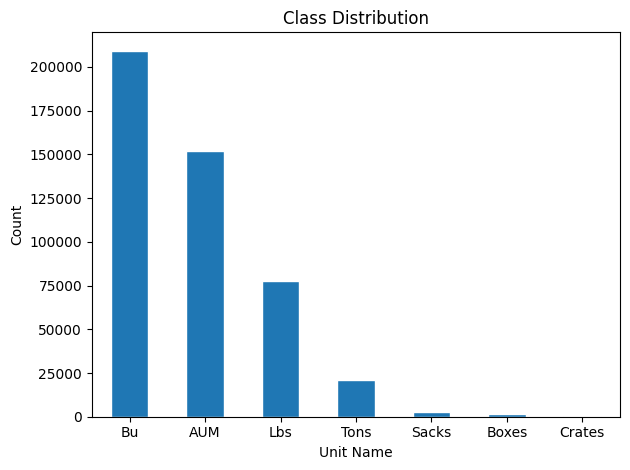

In [52]:
df['yldunits'].value_counts().plot(
    kind='bar',
    edgecolor='white', 
    width=0.5
)

plt.xticks(rotation=0)
plt.title('Class Distribution', fontsize=12)
plt.xlabel('Unit Name')
plt.ylabel('Count')


plt.tight_layout()
plt.show()

* Weight (Tons, Lbs)
* Volume (Bu, Sacks, Boxes, Crates)
* Carrying capacity (AUM)

Since units measure different things, we cannot standardize all of them across the category. For example we cannot convert Boxes to Lbs because a "Box" of oranges doesn't weigh the same as a "Box" of strawberries. 

https://www.grainunitconverter.com/\
In USDA, a sack is almost equivalent to CWT
We arbitrarily set the conversion rate.
Standardize Lbs
| Crop | Unit | Lb |
| --- | --- | --- |
| Anything | 1 US ton | 2000 lbs |
| Grain sorghum | 1 Bu | 56 lbs |
| Corn | 1 Bu | 56 lbs |
| Wheat/Winter wheat | 1 Bu | 60 lbs |
| Oats | 1 Bu | 34 lbs |
| Peaches | 1 Bu | 48 lbs?|
| Soybeans | 1 Bu | 60 lbs |
| Green peas | 1 Bu | 60 lbs |
| Flax | 1 Bu | 56 lbs |
| Rye | 1 Bu | 56 lbs |
| Rice | 1 Bu | 45 lbs? |
| Barley | 1 Bu | 48 lbs |
| Carrots | 1 Bu | 50 lbs? |
| Onions | 1 sack | 100 lbs? |
| Grapefruit | 1 box | 85 lbs? |
| Oranges | 1 box | 90 lbs? |
| Cantaloupe | 1 crate | 80 lbs? |
| Cabbage | 1 crate | 50 lbs? |
| Anything | 1 AUM | 800 lbs? |






In [53]:
weight = df[df['yldunits'].isin(['Tons', 'Lbs'])]['cropname'].unique()
volume = df[df['yldunits'].isin(['Bu', 'Sacks', 'Boxes', 'Crates'])]['cropname'].unique()
capacity = df[df['yldunits'] == 'AUM']['cropname'].unique()

print(weight)
print(volume)
print(capacity)

<StringArray>
[     'Alfalfa hay',      'Cotton lint',    'Grain sorghum',
      'Watermelons',        'Sugarcane',          'Peanuts',
      'Sorghum hay',           'Alfafa',      'Corn silage',
         'Dry peas',   'Sorghum silage',          'Spinach',
       'Legume hay', 'Pima cotton lint',        'Grass hay',
 'Small grains hay',       'Sunflowers']
Length: 17, dtype: str
<StringArray>
['Grain sorghum',         'Wheat',          'Corn',  'Winter wheat',
        'Onions',    'Grapefruit',       'Oranges',          'Oats',
       'Peaches',      'Soybeans',    'Green peas',          'Flax',
          'Rice',        'Barley',       'Carrots',           'Rye',
    'Cantaloupe',       'Cabbage']
Length: 18, dtype: str
<StringArray>
['Improved bermudagrass',     'Weeping lovegrass',          'Buffel grass',
            'Kleingrass',            'Bahiagrass',   'Common bermudagrass',
    'Caucasian bluestem',   'Introduced bluestem', 'Small grains grazeout',
        'Sorghum grazed',  

In [54]:
df = df.drop('yldunits', axis=1)

# ---------------------------------------------

#### Class distribution

In [55]:
# Count of each class
print("Class counts:")
print(df['cropname'].value_counts())

Class counts:
cropname
Improved bermudagrass    80004
Grain sorghum            78269
Cotton lint              60457
Wheat                    54449
Corn                     38812
Common bermudagrass      23256
Oats                     21106
Bahiagrass               16920
Peanuts                  11886
Alfalfa hay              11823
Soybeans                  9630
Small grains grazeout     9258
Weeping lovegrass         6525
Introduced bluestem       5044
Kleingrass                4304
Rice                      3876
Watermelons               3528
Tall fescue               2807
Onions                    2712
Corn silage               2642
Peaches                   1930
Sorghum grazed            1825
Green peas                1572
Winter wheat              1549
Carrots                   1176
Barley                    1091
Sorghum hay                994
Grapefruit                 888
Oranges                    888
Sorghum silage             886
Buffel grass               840
Caucasian bluest

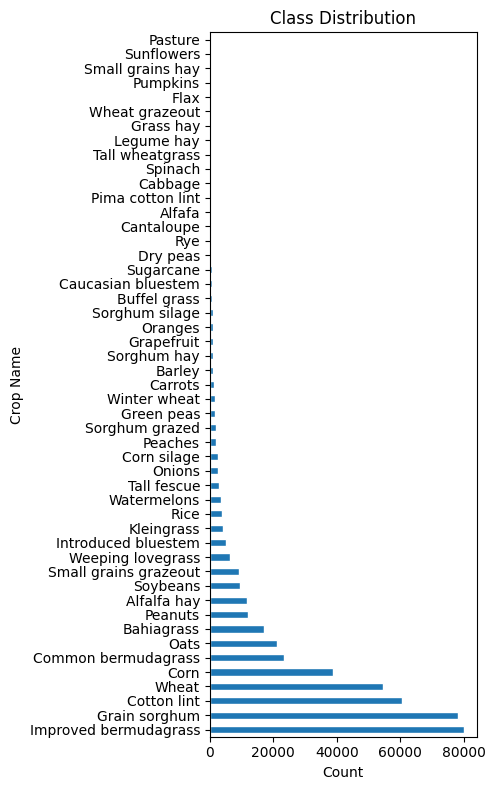

In [56]:
plt.figure(figsize=(5, 8))

# Change 'kind' to 'barh' for horizontal bars
df['cropname'].value_counts().plot(
    kind='barh',
    edgecolor='white', 
    width=0.5
)

# Swap labels to match the new orientation
plt.title('Class Distribution', fontsize=12)
plt.xlabel('Count')       # Now the x-axis shows the count
plt.ylabel('Crop Name')   # Now the y-axis shows the crop names

plt.tight_layout()
plt.show()

#### Map cropname to crop category

In [57]:
# Define the mapping dictionary
crop_mapping = {
    # Cereal Grains
    'Corn': 'Cereal Grains', 'Grain sorghum': 'Cereal Grains', 'Wheat': 'Cereal Grains', 
    'Winter wheat': 'Cereal Grains', 'Oats': 'Cereal Grains', 'Rice': 'Cereal Grains', 
    'Barley': 'Cereal Grains', 'Rye': 'Cereal Grains',
    # Pasture Grasses
    'Improved bermudagrass': 'Pasture Grasses', 'Common bermudagrass': 'Pasture Grasses', 
    'Bahiagrass': 'Pasture Grasses', 'Weeping lovegrass': 'Pasture Grasses', 
    'Introduced bluestem': 'Pasture Grasses', 'Kleingrass': 'Pasture Grasses', 
    'Tall fescue': 'Pasture Grasses', 'Buffel grass': 'Pasture Grasses', 
    'Caucasian bluestem': 'Pasture Grasses', 'Tall wheatgrass': 'Pasture Grasses', 
    'Pasture': 'Pasture Grasses',
    # Hay & Forage
    'Alfalfa hay': 'Hay & Forage', 'Alfafa': 'Hay & Forage', 'Sorghum hay': 'Hay & Forage', 
    'Legume hay': 'Hay & Forage', 'Grass hay': 'Hay & Forage', 'Small grains hay': 'Hay & Forage',
    # Silage & Grazing
    'Corn silage': 'Silage & Grazing', 'Small grains grazeout': 'Silage & Grazing', 
    'Sorghum grazed': 'Silage & Grazing', 'Sorghum silage': 'Silage & Grazing', 
    'Wheat grazeout': 'Silage & Grazing',
    # Fiber Crops
    'Cotton lint': 'Fiber Crops', 'Pima cotton lint': 'Fiber Crops', 'Flax': 'Fiber Crops',
    # Oilseeds & Legumes
    'Peanuts': 'Oilseeds & Legumes', 'Soybeans': 'Oilseeds & Legumes', 
    'Green peas': 'Oilseeds & Legumes', 'Dry peas': 'Oilseeds & Legumes', 
    'Sunflowers': 'Oilseeds & Legumes',
    # Vegetables & Melons
    'Onions': 'Vegetables & Melons', 'Watermelons': 'Vegetables & Melons', 
    'Carrots': 'Vegetables & Melons', 'Spinach': 'Vegetables & Melons', 
    'Cabbage': 'Vegetables & Melons', 'Cantaloupe': 'Vegetables & Melons', 
    'Pumpkins': 'Vegetables & Melons',
    # Fruits
    'Peaches': 'Fruits', 'Grapefruit': 'Fruits', 'Oranges': 'Fruits',
    # Specialty
    'Sugarcane': 'Specialty Crops'
}

# Apply mapping to your dataframe
df['crop_category'] = df['cropname'].map(crop_mapping)
df = df.drop('cropname', axis=1)
print(df['crop_category'].nunique())

9


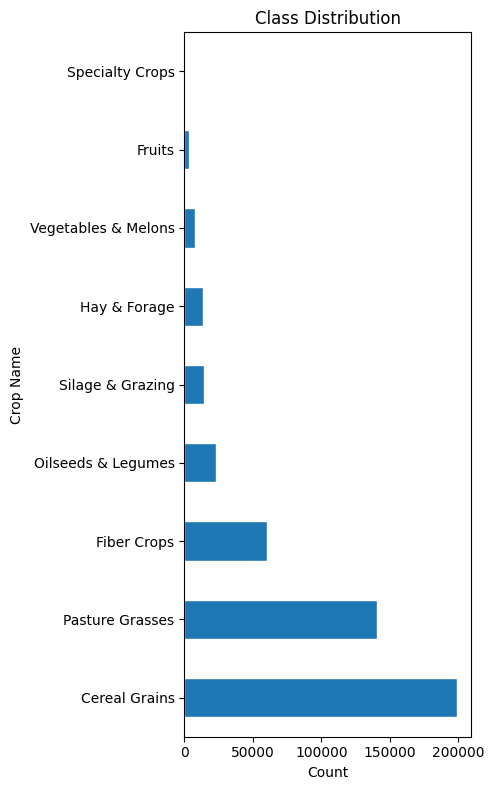

In [58]:
plt.figure(figsize=(5, 8))

# Change 'kind' to 'barh' for horizontal bars
df['crop_category'].value_counts().plot(
    kind='barh',
    edgecolor='white', 
    width=0.5
)

# Swap labels to match the new orientation
plt.title('Class Distribution', fontsize=12)
plt.xlabel('Count')       # Now the x-axis shows the count
plt.ylabel('Crop Name')   # Now the y-axis shows the crop names

plt.tight_layout()
plt.show()

#### Correlation matrix

In [59]:
# Select numeric colmns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeric features:", num_cols.tolist())

# Select categorical columns
cat_cols = df.select_dtypes(include=['str', 'object']).columns
print("Categorical features:", cat_cols.tolist())

Numeric features: ['elev_r', 'slope_r', 'hzdepb_r', 'ph1to1h2o_r', 'om_r', 'ec_r', 'cec7_r', 'awc_r', 'month', 'precip_total_mm', 'tmax_avg_c', 'tmin_avg_c']
Categorical features: ['taxorder', 'drainagecl', 'fips_code', 'crop_category']


In [61]:
# Make a correlation matrix
cm = df[num_cols].corr()
print(cm)

                   elev_r   slope_r  hzdepb_r  ph1to1h2o_r      om_r  \
elev_r           1.000000 -0.060413 -0.066524     0.433452 -0.007022   
slope_r         -0.060413  1.000000 -0.103925    -0.084410 -0.186350   
hzdepb_r        -0.066524 -0.103925  1.000000     0.151034  0.002395   
ph1to1h2o_r      0.433452 -0.084410  0.151034     1.000000  0.285400   
om_r            -0.007022 -0.186350  0.002395     0.285400  1.000000   
ec_r             0.053230 -0.115000  0.050927     0.193505  0.073567   
cec7_r          -0.042040 -0.130106  0.036307     0.457404  0.650842   
awc_r            0.080569 -0.171224 -0.069331     0.311540  0.389882   
month           -0.000049  0.000240 -0.000154    -0.000179 -0.000115   
precip_total_mm -0.145815  0.034403 -0.016623    -0.136837 -0.007720   
tmax_avg_c      -0.133826 -0.020086  0.033514    -0.008004  0.006732   
tmin_avg_c      -0.303702 -0.016219  0.038674    -0.095727  0.020650   

                     ec_r    cec7_r     awc_r     month  precip

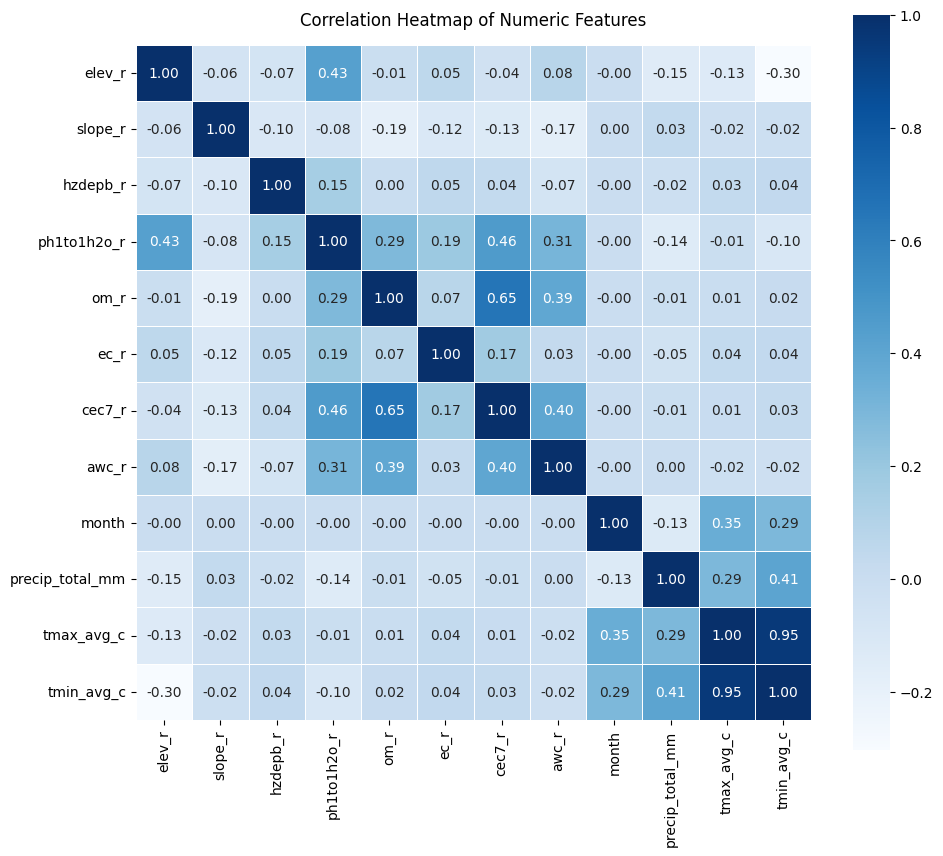

In [62]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    square=True,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=12, pad=14)
plt.tight_layout()
plt.show()

### Train and test split

In [63]:
X = df.drop('crop_category', axis=1)
y = df['crop_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

In [64]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['str', 'object']).columns
print(num_cols)
print(cat_cols)

Index(['elev_r', 'slope_r', 'hzdepb_r', 'ph1to1h2o_r', 'om_r', 'ec_r',
       'cec7_r', 'awc_r', 'month', 'precip_total_mm', 'tmax_avg_c',
       'tmin_avg_c'],
      dtype='str')
Index(['taxorder', 'drainagecl', 'fips_code'], dtype='str')


#### Random Forest pipeline

In [65]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())

])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(
                    drop='first',
                    handle_unknown='ignore',
                    sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42))
])


In [66]:
rf_pipeline.fit(X_train, y_train)
y_train_pred = rf_pipeline.predict(X_train)
y_test_pred = rf_pipeline.predict(X_test)

print(accuracy_score(y_train, y_train_pred))
print(accuracy_score(y_test, y_test_pred))
print(geometric_mean_score(y_train, y_train_pred))
print(geometric_mean_score(y_test, y_test_pred))

0.4701047845795838
0.22494592645998557
0.6306969703845069
0.11387048585717228


In [67]:
from sklearn.metrics import make_scorer
gmean = make_scorer(geometric_mean_score, average='multiclass')

In [ ]:
param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 10, 20]
}


grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring=gmean)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

c:\Users\qurm9\Documents\Math-4650-final-project\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\qurm9\Documents\Math-4650-final-project\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\qurm9\Documents\Math-4650-final-project\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\qurm9\Documents\Math-4650-final-project\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 409, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_lab

In [ ]:
best_model = grid_search.best_estimator_
y_test_pred = best_model.predict(X_test)
print(f"Test G-mean: {geometric_mean_score(y_test, y_test_pred):.4f}")

Test G-mean: 0.3885


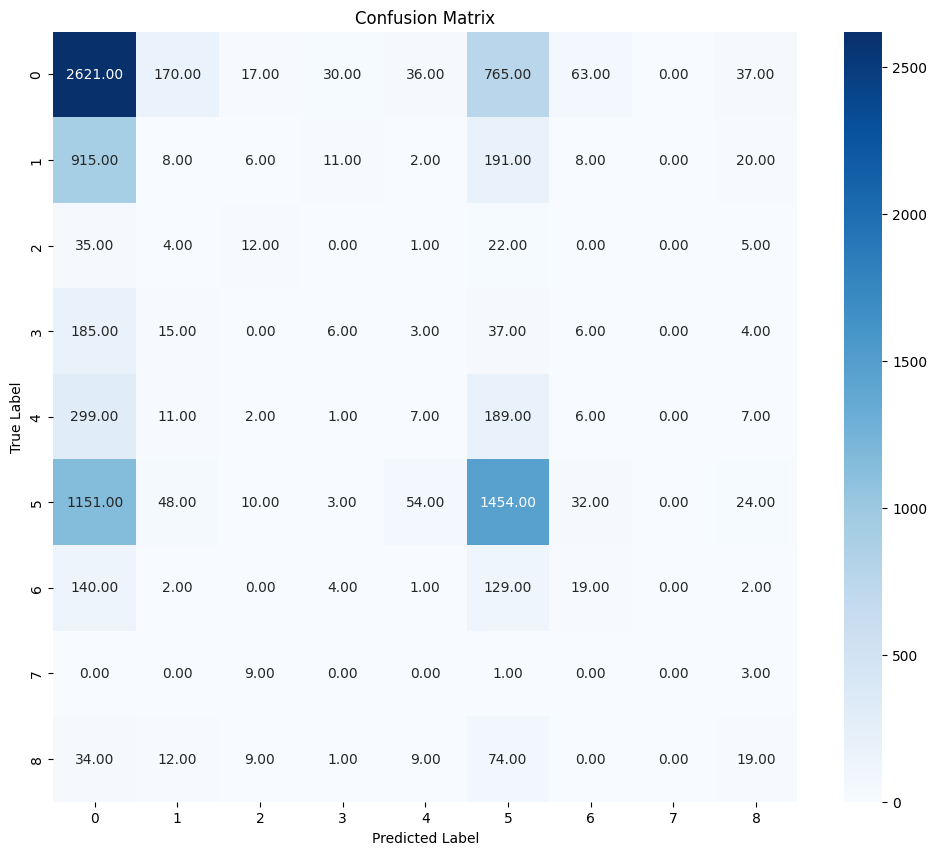

In [ ]:
cnf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cnf_matrix, annot=True, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#### KNN

In [ ]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

In [ ]:
knn_pipeline.fit(X_train, y_train)
y_train_pred = knn_pipeline.predict(X_train)
y_test_pred = knn_pipeline.predict(X_test)

print(accuracy_score(y_train, y_train_pred))
print(accuracy_score(y_test, y_test_pred))
print(geometric_mean_score(y_train, y_train_pred))
print(geometric_mean_score(y_test, y_test_pred))


0.5342610338027387
0.4496167092545273
0.1839355740862508
0.0


In [ ]:
X_train_prepped = preprocessor.fit_transform(X_train)
X_test_prepped = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
knn = KNeighborsClassifier(n_neighbors=5)

sfs = SequentialFeatureSelector(knn, n_features_to_select=5, direction='forward', cv=5)
sfs.fit(X_train_prepped, y_train)

selected_indices = sfs.get_support()
selected_features = feature_names[selected_indices]

knn.fit(X_train_prepped[:, selected_indices], y_train)
result = permutation_importance(
    knn, X_test_prepped[:, selected_indices], y_test, n_repeats=10, random_state=42
)

sorted_idx = result.importances_mean.argsort()

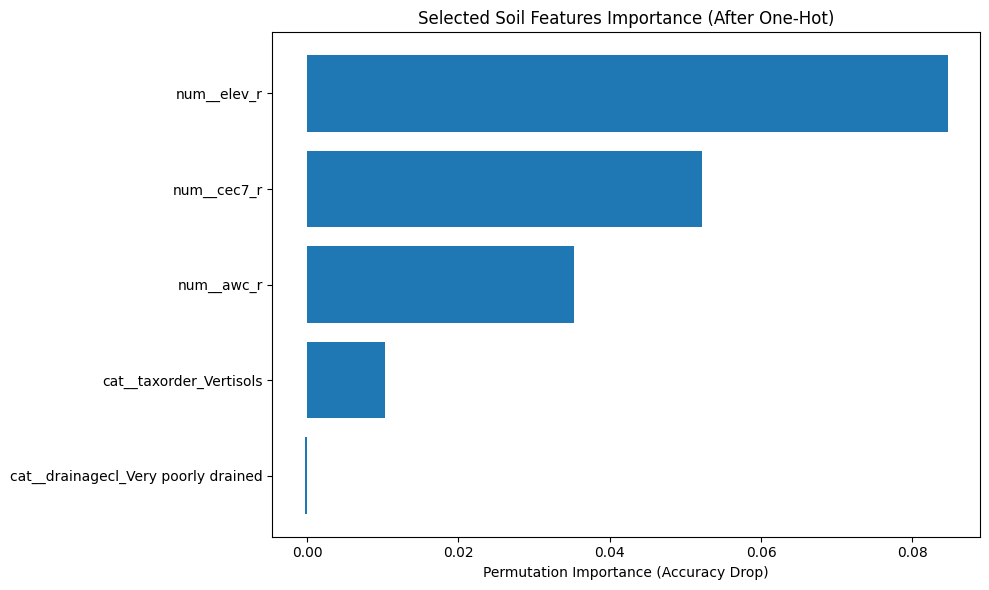

Selected features: ['num__elev_r' 'num__cec7_r' 'num__awc_r' 'cat__taxorder_Vertisols'
 'cat__drainagecl_Very poorly drained']


In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(selected_features[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance (Accuracy Drop)")
plt.title("Selected Soil Features Importance (After One-Hot)")
plt.tight_layout()
plt.show()

print("Selected features:", selected_features)

In [ ]:
selected_features = ['elev_r', 'cec7_r', 'awc_r']
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

simple_knn_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5)) 
])

simple_knn_pipeline.fit(X_train_selected, y_train)
y_train_pred = simple_knn_pipeline.predict(X_train_selected)
y_test_pred = simple_knn_pipeline.predict(X_test_selected)

print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(geometric_mean_score(y_train, y_train_pred))
print(geometric_mean_score(y_test, y_test_pred))

Train Accuracy: 0.5131
Test Accuracy: 0.4594
0.0
0.0


#### Imbalanced random forest

In [ ]:
imb_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('oversample',  SMOTE(random_state=42)),
    ('undersample', RandomUnderSampler(random_state=42)),
    ('rf', RandomForestClassifier(class_weight='balanced'))
])

In [ ]:
imb_pipeline.fit(X_train, y_train)
y_train_pred = imb_pipeline.predict(X_train)
y_test_pred = imb_pipeline.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(geometric_mean_score(y_train, y_train_pred))
print(geometric_mean_score(y_test, y_test_pred))

Train Accuracy: 0.4791
Test Accuracy: 0.3405
0.5140835809310703
0.31325636357225634


In [ ]:
imb_pipeline.classes_

array(['Cereal Grains', 'Fiber Crops', 'Fruits', 'Hay & Forage',
       'Oilseeds & Legumes', 'Pasture Grasses', 'Silage & Grazing',
       'Specialty Crops', 'Vegetables & Melons'], dtype=object)

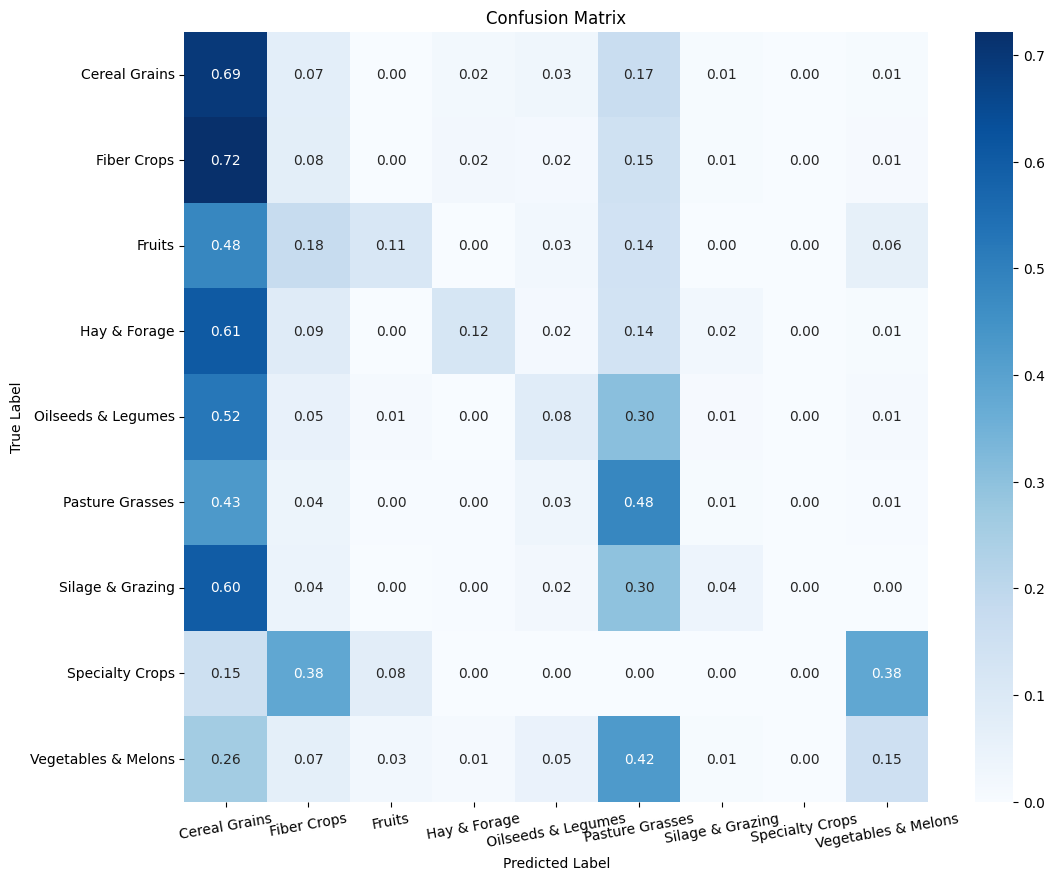

In [ ]:
cnf_matrix = confusion_matrix(y_test, y_test_pred)
cnf_matrix_norm = cnf_matrix.astype('float') / cnf_matrix.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 10))
sns.heatmap(cnf_matrix_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=imb_pipeline.classes_,
            yticklabels=imb_pipeline.classes_)
plt.xticks(rotation=10)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Decrease the number of crop categories